In [1]:
import statsmodels, sklearn
print("statsmodels", statsmodels.__version__)   # 0.13+
print("sklearn", sklearn.__version__)

statsmodels 0.14.6
sklearn 1.8.0


# 20회차 — 회귀 모델 (트랙2: 기상 → 가격)
OLS(HC1) 메인 해석 + Lasso/Ridge/ElasticNet 비교.
설계: 교란(지역·계절·연도) 통제, 매개(등급·육질·체중·증체) 제외 = 총효과.
보조: 매개 포함 직접효과 모델로 간접경로 분해. 농장 단위 분할 재사용.

한마디로 교란 넣고, 매개 제외하고 -> 이게 총 효과다

In [5]:
# ==============================================================
# 라이브러리 + 한글 폰트 (set_style을 폰트보다 먼저!)
# ==============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform, os, json, warnings
warnings.filterwarnings("ignore")

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

sns.set_style("whitegrid")
def set_korean_font():
    s = platform.system()
    if s == "Darwin":      plt.rcParams["font.family"] = "AppleGothic"
    elif s == "Windows":   plt.rcParams["font.family"] = "Malgun Gothic"
    else:                  plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False
set_korean_font()

pd.set_option("display.max_columns", 100)
os.makedirs("../../figures", exist_ok=True)
os.makedirs("../../data/processed/4_model", exist_ok=True)
SEED = 42

In [6]:
# ==============================================================
# step11 + 공유 분할 → 가격 있는 dev 행만
# ==============================================================
df = pd.read_csv("../../data/processed/3_eda/step11_features.csv",
                 encoding="utf-8-sig", low_memory=False)
split = pd.read_csv("../../data/processed/4_model/split_assignment.csv",
                    encoding="utf-8-sig")
df = df.merge(split, on="CATTLE_NO", how="left")
print(f"전체: {df.shape}")

# 회귀 대상: 개발 셋 ∩ 가격 존재
# 회귀분석에 사용할 데이터만 골라서 df_reg를 만듦,가격을 로그로 바꿈
df_reg = df[(df["split"] == "dev") & df["COST_AMT"].notnull()].reset_index(drop=True)
df_reg["log_cost"] = np.log(df_reg["COST_AMT"])     # 전처리에서 COST_AMT > 0 보장됨
print(f"회귀용: {len(df_reg):,}행 (dev의 약 63% — 가격 비공개 37%는 분석 제외)")
print("fold 분포:\n", df_reg["fold"].value_counts().sort_index().to_string())

# 농장 무결성은 자동 유지: fold는 농장 단위로 배정됐고, 행을 "걸러내기만" 했으므로
# 같은 농장이 두 fold에 걸칠 수 없다.
assert (df_reg.groupby("FARM_UNIQUE_NO")["fold"].nunique() > 1).sum() == 0
print("농장-fold 무결성 통과")

# 연도 더미 (연속형 abatt_year는 점 3개라 직선추세를 강제 → 더미로)
year_dum = pd.get_dummies(df_reg["abatt_year"], prefix="ayear", drop_first=True).astype(int)
df_reg = pd.concat([df_reg, year_dum], axis=1)
YEAR_COLS = year_dum.columns.tolist()      # 예: ['ayear_2024', 'ayear_2025']
print("연도 더미:", YEAR_COLS)

# step11이랑 split_assignment 파일을 소 개체번호 기준으로 합침
# 각 소에 split, fold 정보를 붙임
# dev이고, 가격이 있는 회귀분석용 데이터만 고르기
# 가격을 로그로 바꾸기(log_cost)
# fold 분포 확인하고
# 한 농장이 여러 fold에 걸쳐 있지 않은지 검사
# 도축연도(year_dum) 더미 만들기(2023~2025를 0,1로), 즉 기준 연도가 2023이면-> ayear_2024,2025만 생김
# 연도 더미를 df_reg에 붙이기

# 8:2 로 나누면 dev 약 190만개, 가격공개 63%니까 약 120만개
# fold0에 회귀용 데이터 246507행(fold에 들어간 소 개체 행 수)
# 무결성 통과 : 같은 농장의 소가 여러 fold에 섞이지않음, 학습과 검증에 동시에 들어가면 모델이 농장 특성을 외워서 검증해야함
# 더미 생성(기준이 2023년, 2023년 대비 2024,5년 가격 차이)


전체: (2408699, 94)
회귀용: 1,218,345행 (dev의 약 63% — 가격 비공개 37%는 분석 제외)
fold 분포:
 fold
0    246507
1    240981
2    240261
3    246194
4    244402
농장-fold 무결성 통과
연도 더미: ['ayear_2024', 'ayear_2025']


In [7]:
# ==============================================================
# 회귀 우변 변수 — 역할별로 명확히 구분 (1-2·1-3절 설계)
# ==============================================================
# (A) 관심 변수 — 더위(기상)
weather_vars = ["ratio_고온", "ta_min_mean", "rn_day_mean", "ws_davg_mean", "heat_high"]

# (B) 교란 통제 — 더위와 무관하게 가격의 원인 (꼭 넣어야 함)
#     AGE는 '출하 시기 선택'에 가까워 통제(경계선 — 5장에서 제외 민감도 점검)
confounders = (
        ["AGE", "C2025", "AREA", "density", "death_count", "death_rate", "age_optimal",
         "KPN_NO_freq", "FATHER_CATTLE_NO_freq", "MOTHER_ANIMAL_NO_freq"]
        + YEAR_COLS                                       # 연도 더미 (연속형 대신)
        + [c for c in df_reg.columns if c.startswith(
    ("sido_", "abatt_season_", "birth_season_", "sex_"))]
)

# (C) 매개변수 — 더위의 '결과'면서 가격의 원인 → 총효과 모델에선 제외! (1-2절)
mediators = ["WEIGHT", "daily_gain"]

# [완전 제외] grade_num·육질 8·WGRADE(정답지 누수 + 매개),
#            fattening_days(AGE와 VIF 6,400+), ratio_강더위·위험(고온과 중첩),
#            days_* 절대일수(비율로 대체), C2023·C2024(C2025와 r>0.95),
#            Age_squared(비선형은 5장), abatt_month/quarter·birth_year/month(더미와 중복),
#            abatt_year(연속형 → YEAR_COLS 더미로 대체)

# ★ 메인 = 총효과 모델 (매개 제외) / 보조 = 직접효과 모델 (매개 포함)
reg_features        = [c for c in weather_vars + confounders            if c in df_reg.columns]
reg_features_direct = [c for c in weather_vars + confounders + mediators if c in df_reg.columns]
print(f"총효과 모델 변수: {len(reg_features)}개 / 직접효과 모델 변수: {len(reg_features_direct)}개")

# 회귀식 우변에 넣을 변수 목록 정하는 코드(log_cost=더위+교란+오차)
# 관심변수 : 효과를 알고싶은 더위/기상 변수들
# 교란변수 : 더위,가격을 동시에 흔들수있어서 회귀식에 넣어 통제하는 변수
# 매개변수 : 더위의 결과 or 가격으로 이어지는 중간 경로(총 모델에서 제외)
# 총효과 모델 : 더위+교란(더위가 가격에 미치는 전체 효과)
# 직접효과 모델 : 더위 + 교란 + 매개(몸무게,증체같은 조건에서 더위의 남은 효과)
# 변수가 94개인데, 여기서 41,43개인 이유 : 회귀식에는 해석 목적에 맞는 변수만 선별해서 넣기 때문

총효과 모델 변수: 41개 / 직접효과 모델 변수: 43개


In [8]:
#==============================================================
# 결측·무한대 방어 처리
#==============================================================
def prepare_X(train_X, *other_Xs):
    """① inf→NaN ② train 중앙값으로 대치(누수 방지) ③ 전부결측 컬럼 제거"""
    train_X = train_X.replace([np.inf, -np.inf], np.nan)
    med = train_X.median(numeric_only=True)
    out = [train_X.fillna(med)]
    for X_ in other_Xs:
        out.append(X_.replace([np.inf, -np.inf], np.nan).fillna(med))
    bad = out[0].columns[out[0].isnull().any()].tolist()
    if bad:
        print(f"  [방어] 전부 결측 컬럼 제거: {bad}")
        out = [o.drop(columns=bad) for o in out]
    return out if len(out) > 1 else out[0]

X_full = prepare_X(df_reg[reg_features])
y_full = df_reg["log_cost"]
print(f"X: {X_full.shape}")

# 총효과 회귀모델에 넣을 41개 설명변수에 결측,무한 처리하고, 종속변수 log_cost와 함께 회귀분석 준비 끝내는 코드
# 무한대 결측값을 NaN으로 바꿈
# 결측값을 중앙값으로 채움
# OLS회귀는 NaN이나 inf가 있으면 실행 안됨
# 중앙값으로도 채워지지 않는 컬럼 확인(컬럼전체가 결측)-> 전부 결측은 제거
# 총효과 모델에 넣을 설명변수 41개 준비(독립변수)
# 회귀의 종속변수는 로그 가격

# 회귀에 사용할 입력변수 X는 120만 행, 41개 변수

X: (1218345, 41)


In [23]:
# ==============================================================
# 고속 VIF: 상관행렬 역행렬의 대각 = VIF  (실데이터 검증 완료)
# ==============================================================
def fast_vif(X):
    zero_var = X.columns[X.std() == 0].tolist()   # 분산 0이면 상관 정의 불가 → 방어
    Xv = X.drop(columns=zero_var)
    corr = Xv.corr().values
    vif = pd.Series(np.diag(np.linalg.pinv(corr)), index=Xv.columns)
    return vif.sort_values(ascending=False), zero_var

VIF_LIMIT = 10
removed = []
while True:
    vif, zv = fast_vif(X_full)
    removed += zv
    X_full = X_full.drop(columns=zv) if zv else X_full
    if vif.iloc[0] <= VIF_LIMIT:
        break
    worst = vif.index[0]
    print(f"제거: {worst} (VIF={vif.iloc[0]:.1f})")
    X_full = X_full.drop(columns=[worst]); removed.append(worst)

print(f"\n최종 변수 {X_full.shape[1]}개 (제거: {removed if removed else '없음'})")
print("VIF 상위 10:")
print(vif.head(10).round(2).to_string())

# KPN_NO_freq(vif=108.3) 이미 한번 실행해서 제거된 상태(1개 제거)
# 설명변수들 사이 다중공선성을 VIF로 확인하고 높은 변수들 제거
# 5~10은 심각한 수준은 아니기때문에 제거 안해도됌


최종 변수 40개 (제거: 없음)
VIF 상위 10:
MOTHER_ANIMAL_NO_freq    7.52
FATHER_CATTLE_NO_freq    7.27
sido_경상북도                5.17
ratio_고온                 4.28
sido_전라남도                4.20
sido_충청남도                3.73
sido_전북특별자치도             3.57
sido_경상남도                3.37
birth_season_봄           3.05
sido_경기도                 2.74


In [10]:
# ==============================================================
# OLS — 원 단위 + 이분산 강건(HC1) 표준오차
# OLS 회귀모델이 실제로 적합하고 모델 전체 성능을 확인하기 위함
# ==============================================================
Xc = sm.add_constant(X_full)
ols = sm.OLS(y_full, Xc).fit(cov_type="HC1")

print(f"n          : {int(ols.nobs):,}")
print(f"R²         : {ols.rsquared:.4f}")
print(f"Adj R²     : {ols.rsquared_adj:.4f}")
print(f"F p-value  : {ols.f_pvalue:.3g}")
print(f"AIC / BIC  : {ols.aic:,.0f} / {ols.bic:,.0f}")

# 회귀에 사용된 행 수
# 모델이 로그 가격 변동의 약 41.03%를 설명함
# F p-value=0 : 모델 전체가 통계적으로 유의함(표본이 커서 당연한거, 효과크기와 신뢰구간을 봐야함)(너무 작아서 0으로 나온거)(<0.05 유의)
# AIC/BIC : 모델 적합도와 복잡도를 함께 평가하는 비교용 지표, 값이 낮을수록 좋음, 근데 해석보단 다른 회귀모델 사양과 비교할때 의미가 있음
# 예를 들어
# 모델1 AIC = -100
# 모델2 AIC = -200  -> 모델2가 더 좋음

n          : 1,218,345
R²         : 0.4103
Adj R²     : 0.4103
F p-value  : 0
AIC / BIC  : -247,687 / -247,195


In [11]:
# ==============================================================
# 계수표 — 두 가지 해석을 한 표에
# 가격에 영향을 주는 변수들이 무엇이고, 그 영향의 방향과 크기가 어느정도인지
# 변수가 가격과 관련이 큰가? 올리는 방향,낮추는 방향? 통계적으로 안정적?
# ==============================================================
sd = X_full.std()
ci = ols.conf_int()

coef = pd.DataFrame({
    "계수β":     ols.params,
    "강건SE":    ols.bse,
    "p":         ols.pvalues,
    "CI하한":    ci[0],
    "CI상한":    ci[1],
}).drop(index="const")
coef["효과%_1단위"] = (np.exp(coef["계수β"]) - 1) * 100        # 정확식
coef["효과%_1SD"]  = (np.exp(coef["계수β"] * sd) - 1) * 100    # 영향력 비교용
coef["유의"] = coef["p"].apply(
    lambda p: "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "")
coef = coef.reindex(coef["효과%_1SD"].abs().sort_values(ascending=False).index)

print("=== 1-SD 영향력 순 상위 20 ===")
print(coef.head(20).round(4).to_string())
coef.to_csv("../../data/processed/4_model/20_ols_coef.csv", encoding="utf-8-sig")

# 효과 %_1단위 = 해당 변수가 1증가할때 가격이 몇% 변하는지

# ratio_고온은 0~1 비율임 -> 효과%_1단위로 해석하면 안되고, 1%p로 해석해야함
# 고온노출 1%p 증가=0.01 증가 | 가격 변화=(exp(0.4351*0.01)-1) * 100 = +0.436%
# 같은 지역,계절,연도,성별,월령,농장 조건에서 생애 고온노출 비율이 1%p 증가하면 가격은 약 0.44% 높다.(ratio_고온)

# AGE : 강건 SE 매우작음 -> AGE계수는 -0.0045 근처에서 안정적으로 추정됐다 -> 이래서 신뢰구간도 좁음
# 즉 , 월령이 증가할수록 가격이 낮아지는 방향이 꽤 안정적이다.

# 보고서 예시 : 이분산 가능성을 고려해도 ratio_고온의 계수는 0.4351 근처에서 비교적 안정적으로 추정되었고, 95% 신뢰구간도 전부 양수이므로 고온노출 비율과 가격의 양의관계는 통계적으로 안정적이다.

=== 1-SD 영향력 순 상위 20 ===
                          계수β    강건SE    p    CI하한    CI상한  효과%_1단위  효과%_1SD   유의
AGE                   -0.0045  0.0000  0.0 -0.0046 -0.0045  -0.4537 -10.2205  ***
ayear_2025             0.1202  0.0006  0.0  0.1191  0.1214  12.7743   5.8109  ***
sex_암                 -0.1032  0.0005  0.0 -0.1042 -0.1022  -9.8067  -5.0291  ***
abatt_season_봄        -0.0907  0.0008  0.0 -0.0923 -0.0890  -8.6679  -3.7797  ***
sex_수                 -0.6127  0.0055  0.0 -0.6234 -0.6020 -45.8125  -3.4974  ***
abatt_season_여름       -0.0778  0.0007  0.0 -0.0791 -0.0765  -7.4828  -3.2994  ***
abatt_season_겨울       -0.0601  0.0006  0.0 -0.0613 -0.0589  -5.8359  -2.6227  ***
ratio_고온               0.4351  0.0106  0.0  0.4142  0.4560  54.5100   2.2029  ***
age_optimal            0.0327  0.0005  0.0  0.0317  0.0337   3.3210   1.6179  ***
death_count           -0.0008  0.0000  0.0 -0.0008 -0.0008  -0.0787  -1.4324  ***
C2025                  0.0001  0.0000  0.0  0.0001  0.0001   0.0059   1.1

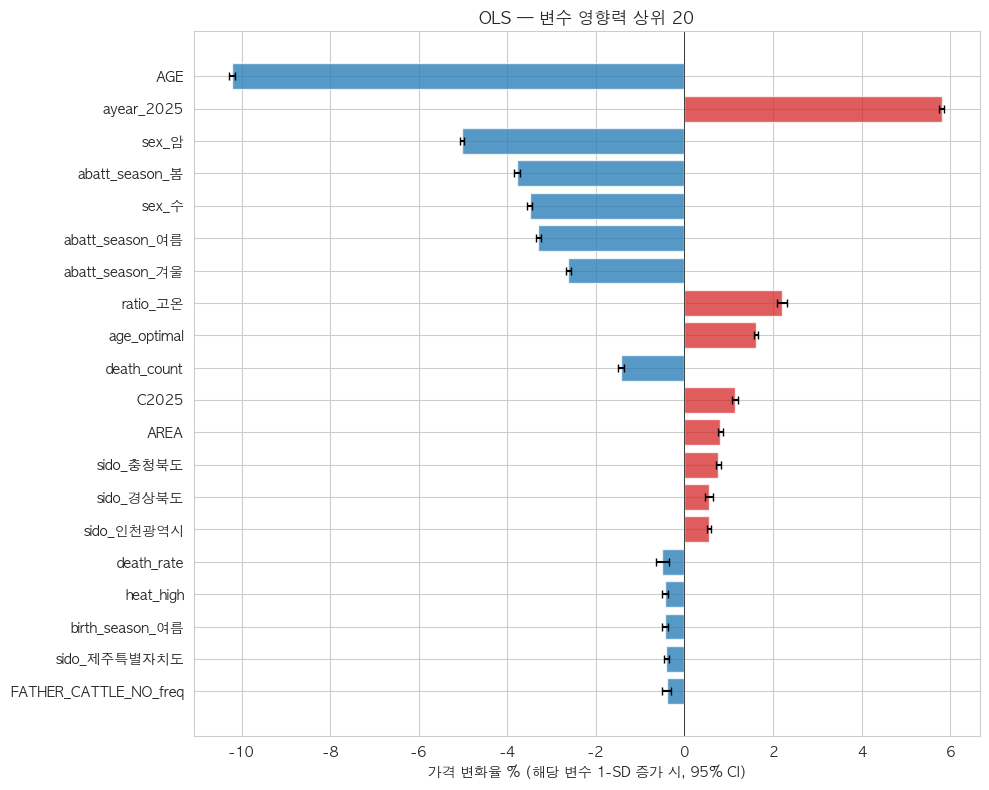

In [12]:
# ==============================================================
# 영향력 상위 20 시각화(1-SD + 신뢰구간)
# ==============================================================
top = coef.head(20).iloc[::-1]
lo = (np.exp(top["CI하한"] * sd[top.index]) - 1) * 100
hi = (np.exp(top["CI상한"] * sd[top.index]) - 1) * 100

plt.figure(figsize=(10, 8))
colors = ["#d62728" if v > 0 else "#1f77b4" for v in top["효과%_1SD"]]
plt.barh(top.index, top["효과%_1SD"], color=colors, alpha=0.75)
plt.errorbar(top["효과%_1SD"], range(len(top)),
             xerr=[top["효과%_1SD"]-lo, hi-top["효과%_1SD"]],
             fmt="none", ecolor="black", capsize=3)
plt.axvline(0, color="black", lw=0.5)
plt.xlabel("가격 변화율 % (해당 변수 1-SD 증가 시, 95% CI)")
plt.title("OLS — 변수 영향력 상위 20")
plt.tight_layout()
plt.savefig("../../figures/20_ols_coef.png", dpi=100, bbox_inches="tight")

# 효과%_1SD 절댓값이 큰 순서로 정렬함
# 검은 오차막대 :이 변수의 효과값이 있을것으로 추정되는 95%신뢰구간
plt.show()

In [13]:
# ==============================================================
# 기상 변수 한계효과 — 보고서의 핵심 문장 재료
# 기상변수들이 가격과 어떤 관계? 보고서 문장으로 바로 쓸수있게 정리하려는 코드
# 핵심 주제 : 기상이 가격과 어떤 관계인가? 이거를 확인하기 위해 기상변수만 따로 뽑아서 해석함
# ==============================================================
weather_vars = [v for v in ["ratio_고온","ta_min_mean","rn_day_mean",
                            "ws_davg_mean","heat_high"] if v in coef.index]
print("=== 기상 변수 효과 ===")
for v in weather_vars:
    b, p = coef.loc[v, "계수β"], coef.loc[v, "p"]
    lo_, hi_ = coef.loc[v, "CI하한"], coef.loc[v, "CI상한"]
    if v == "ratio_고온":   # 비율(0~1) → 0.01(=1%p) 단위가 자연스러움
        eff   = (np.exp(b*0.01)-1)*100
        eff_l = (np.exp(lo_*0.01)-1)*100; eff_h = (np.exp(hi_*0.01)-1)*100
        print(f"{v}: 생애 더위노출 1%p ↑ → 가격 {eff:+.3f}% "
              f"(95% CI {eff_l:+.3f}~{eff_h:+.3f}) p={p:.3g}")
    elif v == "heat_high":  # 더미 → 기준(하위 75%) 대비
        eff = (np.exp(b)-1)*100
        print(f"{v}: 고온노출 상위25% 소는 그 외 대비 가격 {eff:+.2f}% p={p:.3g}")
    else:
        eff = (np.exp(b)-1)*100
        print(f"{v}: 1단위 ↑ → 가격 {eff:+.3f}% p={p:.3g}")

# 마리당 금액 환산 시나리오
avg_price  = df_reg["COST_AMT"].mean()
avg_weight = df_reg["WEIGHT"].mean()
b = coef.loc["ratio_고온", "계수β"]
for dpp in [0.01, 0.05]:        # 더위노출 +1%p, +5%p 시나리오
    pct = (np.exp(b*dpp)-1)*100
    won = avg_price * pct/100 * avg_weight
    print(f"\n시나리오: 생애 더위노출 +{dpp*100:.0f}%p → 가격 {pct:+.2f}% "
          f"→ 마리당 약 {won:+,.0f}원 (평균가 {avg_price:,.0f}원/kg × {avg_weight:.0f}kg)")


# ratio_고온은 0~1비율이라 1단위가 아닌, 1%p = 0.01 기준으로 해석

# ========해석=========
# 1. 같은 지역,계절,연도,성별,월령,농장 조건에서 생애 고온노출 비율이 1%p 증가하면 가격은 약 0.436% 높에 나타났다.(더위가 가격을 올린다 x -> 통제후에도 고온노출 비율이 높은 소에서 가격이 높게 나타났다.o)
# 2. 주요 교란변수를 통제한 조건에서, 평균 일최저기온이 1도 증가할 때 가격은 약 0.09% 높게 나타났다.(ta_min_mean)
# 3. 주요 교란변수를 통제한 조건에서, 평균 일강수량이 1mm 증가할 때 가격은 약 0.12% 높게 나타났다.(rn_day_mean)
# 4. 주요 교란변수를 통제한 조건에서, 평균 일평균풍속이 1m/s 증가할 때 가격은 약 0.33% 높게 나타났다.(ws_davg_mean)
# 5. 주요 교란변수를 통제한 조건에서, 고온노출 비율이 상위 25%인 소는 그 외 소들보다 가격이 약 1.01% 낮게 나타났다.(heat_high)

# -> ratio_고온은 양수인데, heat_high은 음수인 이유는, 일반적 고온노출 비율 증가는 가격과 양의 관계를 보이지만, 매우 높은 고온노출 구간에서는 가격 패널티가 나타날 가능성
# 가격 패널티 : 어떤 조건에 해당하는 그룹이 가격에서 불리하게 나타나는것(고온노출이 너무 높은 그룹에서 가격이 깎이는 듯한 불리한 효과)-> 상위 고온노출 그룹이 가격에서 불리하게 나타났다라고 해석

# 한계효과 : 기상변수가 한 단위 변할 떄 가격이 얼마나 변하는가

# 이건 보고서 양식 : 같은 지역·연도·계절·성별·월령·농장 특성 및 혈통 빈도를 통제한 OLS(HC1) 결과, 고온노출 상위 25% 그룹은 그 외 그룹 대비 가격이 약 1.01% 낮게 나타났다.

=== 기상 변수 효과 ===
ratio_고온: 생애 더위노출 1%p ↑ → 가격 +0.436% (95% CI +0.415~+0.457) p=0
ta_min_mean: 1단위 ↑ → 가격 +0.090% p=2.44e-06
rn_day_mean: 1단위 ↑ → 가격 +0.120% p=0.00883
ws_davg_mean: 1단위 ↑ → 가격 +0.330% p=9.67e-10
heat_high: 고온노출 상위25% 소는 그 외 대비 가격 -1.01% p=7.13e-41

시나리오: 생애 더위노출 +1%p → 가격 +0.44% → 마리당 약 +30,465원 (평균가 16,661원/kg × 419kg)

시나리오: 생애 더위노출 +5%p → 가격 +2.20% → 마리당 약 +153,658원 (평균가 16,661원/kg × 419kg)


In [14]:
# ==============================================================
# 매개(WEIGHT·daily_gain) 포함/제외 두 모델 비교 → 간접효과 추출
#   총효과(메인) = 위 ols / 직접효과 = 체격까지 통제한 모델

# 고온노출 효과가 체중,증체를 통해 얼마나 설명되는지 확인하기 위함
# ==============================================================
X_direct = prepare_X(df_reg[reg_features_direct])
ols_direct = sm.OLS(y_full, sm.add_constant(X_direct)).fit(cov_type="HC1")

b_total  = ols.params["ratio_고온"]            # 매개 제외 (총효과)
b_direct = ols_direct.params["ratio_고온"]     # 매개 포함 (직접효과)
eff_total  = (np.exp(b_total  * 0.01) - 1) * 100
eff_direct = (np.exp(b_direct * 0.01) - 1) * 100

print(f"총효과   (체격 미통제): 더위 1%p ↑ → 가격 {eff_total:+.3f}%  (R²={ols.rsquared:.3f})")
print(f"직접효과 (체격 통제)  : 더위 1%p ↑ → 가격 {eff_direct:+.3f}%  (R²={ols_direct.rsquared:.3f})")
print(f"→ 간접효과(더위가 체중·증체를 통해): 약 {eff_total - eff_direct:+.3f}%p")
print("   해석: 더위 효과 중 이만큼이 '체중·증체를 떨어뜨려서' 가격에 작용한 몫.")

# 총효과 : 체중,증체 경로를 막지않은 더위의 전체효과
# 직접효과 : 체중,증체가 같은 조건에서 더위가 가격에 미치는 효과
# 간접효과 : 총효과 - 직접효과, 체중,증체 경로를 통해 설명되는 차이

# 총효과 : 체중,증체를 회귀식에 포함하지 않은 총효과 모델에서, 고온노출 비율이 1%p 증가할때 가격은 약 0.436% 높게 나타났다.
# 정확한 문장 : 체중,증체를 통제하지않은 총효과 모델에서, 주요 교란변수를 통제한후에도 생애 고온노출 비율이 1%p 높은 소는 가격이 약 0.436% 높게 나타났다.

# 직접효과 : 체중,증체를 회귀식에 포함한 직적효과 모델에서, 고온노출 비율이 1%p 증가할때 가격은 약 0.418% 높게 나타났다.
# 정확한 문장 : 체중,증체와 주요 교란변수를 통제한 직접효과 모델에서, 생애 고온노출 비율이 1%p 높은 소는 가격이 약 0.418% 높게 나타났다.

# 간접효과 : 총효과와 직접효과의 차이로, 체중,증체 경로를 통해 설명되는 효과 차이다.
# 이번 결과에서는 0.018%p로 매우 작아, 체중,증체를 통한 간접경로의 비중은 크지 않아 보인다.

# 총 결론 : 체중·증체를 통제하지 않은 총효과 모델에서는 고온노출 1%p 증가가 가격 +0.436%와 관련되었고, 체중·증체를 통제한 직접효과 모델에서는 +0.418%와 관련되었다. 두 값의 차이는 +0.018%p로 매우 작기 때문에, 이번 결과에서는 고온노출 효과 중 체중·증체를 통한 간접경로의 비중은 크지 않은 것으로 보인다.

# 총 : log_cost = 고온노출 + 교란변수 + 오차
# 직접: log_cost = 고온노출 + 교란변수 + WEIGHT + daily_gain + 오차

# 간접 경로 : 더위 -> (간접경로) -> 가격 , 더위가 가격에 영향을 주는 중간 길

총효과   (체격 미통제): 더위 1%p ↑ → 가격 +0.436%  (R²=0.410)
직접효과 (체격 통제)  : 더위 1%p ↑ → 가격 +0.418%  (R²=0.517)
→ 간접효과(더위가 체중·증체를 통해): 약 +0.018%p
   해석: 더위 효과 중 이만큼이 '체중·증체를 떨어뜨려서' 가격에 작용한 몫.


In [15]:
# ==============================================================
# 농장 클러스터 SE — 같은 농장 소들의 오차 상관까지 반영 (가장 보수적)
# 기상변수 효과가 농장 단위로 묶어봐도 여전히 믿을만한지 확인하는 강건성 점검
# 같은 농장 소들이 서로 비슷하다는 점을 고려해도 기상변수 효과가 유의하게 유지되는가?
# ==============================================================
ols_cl = sm.OLS(y_full, Xc).fit(
    cov_type="cluster", cov_kwds={"groups": df_reg["FARM_UNIQUE_NO"]})

chk = pd.DataFrame({
    "계수β": ols.params, "HC1_p": ols.pvalues, "클러스터_p": ols_cl.pvalues
}).loc[weather_vars].round(4)
print(chk.to_string())
print("\n→ 두 p값의 유의성 결론이 같으면 결과가 견고. "
      "클러스터에서만 유의성이 사라지면 '농장 수준 현상'일 가능성 — 보고서에 명시.")

# 기상변수들의 유의성이 표준오차 방식에 따라 유지되는지 확인하는 강건성 점검
# HC1 : 이분산이 있어도 표준오차를 더 안전하게 계산
# 클러스터_p : 농장 단위 클러스터 표준오차를 사용한 p값(HC1보다 엄격함)

#  ratio_고온 : 고온노출 비율 효과는 HC1기준에서도, 농장 클러스터 기준에서도 유의함(농장 단위 상관을 고려해도 견고함)
# ta_min_mean : 평균 일최저기온은 HC1기준으로는 유의하지만, 농장 클러스터 표준 오차를 적용하면 유의하지않음(농장 단위로 묶어보면 신뢰도가 떨어짐)
# rn_day_mean : 평균 일강수량은 HC1에서 유의하지만, 농장 클러스터 기준에선 유의하지않음
# ws_davg_mean : 평균 일평균풍속은 HC1 기준에서 유의하지만, 농장 클러스터 기준에선 유의하지않음
# heat_high : 고온노출 상위 25% 더미는 두 기준 모두에서 유의함(음의 효과는 비교적 견고함)

# 보고서 : 농장단위 클러스터 표준오차 적용한 결과, ratio_고온과 heat_high는 여전히 유의했지만, 평균 일최저기온,일강수량,일평균풍속의 유의성은 사라졌다. 따라서 고온노출 비율 관련 변수는 비교적 견고한 결과로 볼수있다.

                 계수β   HC1_p  클러스터_p
ratio_고온      0.4351  0.0000  0.0000
ta_min_mean   0.0009  0.0000  0.2115
rn_day_mean   0.0012  0.0088  0.4580
ws_davg_mean  0.0033  0.0000  0.1647
heat_high    -0.0102  0.0000  0.0000

→ 두 p값의 유의성 결론이 같으면 결과가 견고. 클러스터에서만 유의성이 사라지면 '농장 수준 현상'일 가능성 — 보고서에 명시.


In [16]:
# ==============================================================
# Lasso / Ridge / ElasticNet — 표준화 후, 분류팀과 같은 fold로 CV
# ==============================================================
LASSO_ALPHA, RIDGE_ALPHA = 0.001, 1.0      # TODO: 5장 가이드로 탐색
EN_ALPHA, EN_L1 = 0.001, 0.5 # 0(릿지) ~ 1(라쏘)

folds = [(np.where(df_reg["fold"] != k)[0], np.where(df_reg["fold"] == k)[0])
         for k in range(5)]
makers = {
    "OLS":        lambda: LinearRegression(),
    "Lasso":      lambda: Lasso(alpha=LASSO_ALPHA, max_iter=10000, random_state=SEED),
    "Ridge":      lambda: Ridge(alpha=RIDGE_ALPHA, random_state=SEED),
    "ElasticNet": lambda: ElasticNet(alpha=EN_ALPHA, l1_ratio=EN_L1,
                                     max_iter=10000, random_state=SEED),
}
cv = {m: {"r2": [], "rmse": []} for m in makers}
nz_last = {}
for tr_idx, va_idx in folds:
    X_tr, X_va = prepare_X(df_reg[reg_features].iloc[tr_idx],
                           df_reg[reg_features].iloc[va_idx])
    y_tr, y_va = y_full.iloc[tr_idx], y_full.iloc[va_idx]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr); X_va_s = sc.transform(X_va)   # train으로만 fit
    for name, mk in makers.items():
        m = mk().fit(X_tr_s, y_tr)
        pred = m.predict(X_va_s)
        cv[name]["r2"].append(r2_score(y_va, pred))
        cv[name]["rmse"].append(np.sqrt(mean_squared_error(y_va, pred)))
        if hasattr(m, "coef_"):
            nz_last[name] = int((np.abs(m.coef_) > 1e-10).sum())

cv_summary = pd.DataFrame({
    "모델": list(makers),
    "R²평균":   [np.mean(cv[m]["r2"]) for m in makers],
    "R²표준편차":[np.std(cv[m]["r2"])  for m in makers],
    "RMSE평균": [np.mean(cv[m]["rmse"]) for m in makers],
    "비영(≠0)계수": [nz_last.get(m, X_tr.shape[1]) for m in makers],
}).round(4)
print(cv_summary.to_string(index=False))
cv_summary.to_csv("../../data/processed/4_model/20_cv_results.csv",
                  index=False, encoding="utf-8-sig")

# 회귀결과가 특정 모델에만 의존하는지 확인하는 코드
# EN_L1 = 엘라스틱넷에서 라쏘와 릿지 규제를 얼마나 섞을지 정하는 비율

# R²평균 : 5개 fold에서 나온 R²의 평균
# R² 표준편차 : fold마다 R²가 얼마나 흔들렸는지
# RMSE 평균 : 5개 fold의 평균 RMSE
# 비영계수 : 계수가 0이 아닌 변수 개수(모델이 실제로 사용한 변수 개수)
# 예시 : Lasso 비영개수 = 29 (전체40개 변수중 29개만 살리고 나머지는 계수를 0으로 만들어 제거함)

# 4개 모델 R² 거의 똑같음 : 모델 바꿔도 설명력은 거의 변하지않음(결과가 특정 모델 하나에만 의존하지않는다는 강건성 신호)
# R²표준편차 : fold마다 성능 흔들림 작음(성능이 비교적 안정적)
# RMSE 평균 : 예측오차도 4개 모델이 거의 비슷함

# 모든 모델 R²와 RMSE가 거의 동일하게 나타남. 이는 회귀 결과가 특정 모델 선택에 크게 의존하지 않는다는 것을 보여줌.
# 특히 Lasso는 40개 변수중 29개만 사용하면서도 OLS와 거의 같은 성능을 보여, 일부 변수는 중복되거나 영향이 작을 가능성이 있음.

# 보고서 : 규제회귀와 OLS의 교차검증 성능이 거의 동일해, 모델 선택에 따른 결과 차이는 크지 않았으며, 회귀결과는 비교적 안정적인것으로 판단된다.

        모델   R²평균  R²표준편차  RMSE평균  비영(≠0)계수
       OLS 0.4083  0.0069  0.2189        40
     Lasso 0.4079  0.0064  0.2190        29
     Ridge 0.4083  0.0069  0.2189        40
ElasticNet 0.4082  0.0066  0.2190        34


In [17]:
# X_tr_s,y_tr에 의존x, 전체 회귀용 데이터에서 다시 표준화해서 알파를 찾는 방식
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

SEED = 42

X_for_cv = prepare_X(df_reg[reg_features])
y_for_cv = y_full

sc = StandardScaler()
X_for_cv_s = sc.fit_transform(X_for_cv)

lcv = LassoCV(
    alphas=np.logspace(-5, 0, 30),
    cv=5,
    max_iter=10000,
    random_state=SEED
).fit(X_for_cv_s, y_for_cv)

print("최적 Lasso alpha:", lcv.alpha_)

LASSO_ALPHA = lcv.alpha_
# RidgeCV(alphas=np.logspace(-3, 3, 30)), ElasticNetCV(l1_ratio=[.2,.5,.8])도 동일 요령

# 0.00001

최적 Lasso alpha: 1e-05


In [22]:
# ==============================================================
# Lasso 생존 변수 — VIF 제거 후 변수 기준
# ==============================================================

X_lasso = X_full.copy()

X_all_s = StandardScaler().fit_transform(X_lasso)

lasso_full = Lasso(alpha=LASSO_ALPHA, max_iter=10000, random_state=SEED) \
    .fit(X_all_s, y_full)

alive = (pd.DataFrame({
    "변수": X_lasso.columns,
    "Lasso계수(표준화)": lasso_full.coef_
})
         .query("abs(`Lasso계수(표준화)`) > 1e-10")
         .sort_values("Lasso계수(표준화)", key=np.abs, ascending=False))

print(f"생존 {len(alive)}개 / {X_lasso.shape[1]}개")
print(alive.head(20).round(4).to_string(index=False))

alive.to_csv("../../data/processed/4_model/20_lasso_coef.csv",
             index=False, encoding="utf-8-sig")

# Lasso의 40개변수중 쓸 변수만 남긴 결과
# Lasso는 중요X,겹치는 변수의 계수를 0으로 만들어 제거함

# AGE는 가격 설명에 가장 강한 변수중 하나임

# 라쏘-> 완전 0으로 만듦 / 릿지-> 계수 작게는 줄임 / EN-> 순수 변수선택은 아님, 선택+안정화 절충에 가까움

# 보고서 : 최적의 알파값은 0.00001이었고, 이 경우 41개 변수가 모두 생존하였다. 이는 예측 성능 기준으로는 강한 변수 제거가 필요하지 않다는 뜻이다.

생존 40개 / 40개
             변수  Lasso계수(표준화)
            AGE       -0.1078
     ayear_2025        0.0565
          sex_암       -0.0516
 abatt_season_봄       -0.0385
          sex_수       -0.0356
abatt_season_여름       -0.0335
abatt_season_겨울       -0.0265
       ratio_고온        0.0217
    age_optimal        0.0160
    death_count       -0.0144
          C2025        0.0113
           AREA        0.0080
      sido_충청북도        0.0076
      sido_경상북도        0.0055
     sido_인천광역시        0.0055
     death_rate       -0.0050
      heat_high       -0.0044
birth_season_여름       -0.0043
   sido_제주특별자치도       -0.0041
      sido_충청남도       -0.0039


In [24]:
# ==============================================================
# 아티팩트 저장
# ==============================================================
joblib.dump({
    "ols_result_params": ols.params, "ols_hc1_bse": ols.bse,
    "X_columns": list(X_full.columns), "removed_by_vif": removed,
    "reg_features": reg_features, "n_obs": int(ols.nobs),
}, "../../data/processed/4_model/20_regression_artifacts.pkl")

resid = pd.DataFrame({"CATTLE_NO": df_reg["CATTLE_NO"],
                      "fitted": ols.fittedvalues, "resid": ols.resid})
resid.to_csv("../../data/processed/4_model/20_residuals.csv",
             index=False, encoding="utf-8-sig")
print("저장 완료: 20_ols_coef / 20_cv_results / 20_lasso_coef / "
      "20_regression_artifacts.pkl / 20_residuals.csv")

저장 완료: 20_ols_coef / 20_cv_results / 20_lasso_coef / 20_regression_artifacts.pkl / 20_residuals.csv


In [19]:
# ==============================================================
# 셀17. 모형 사양 개선: 비선형 / 상호작용 / 결측 정보화
# 사양개선 모형 = 보조분석,강건성 확인, 추가 인사이트
# 최종 대표 문장은 기본모형 기준으로 쓰고, 사양개선은 비선형 확인으로 보조 제시하는게 좋음
# ==============================================================

df_spec = df_reg.copy()

# 1. 비선형: AGE 중심화 제곱
df_spec["AGE_c"] = df_spec["AGE"] - df_spec["AGE"].mean()
df_spec["AGE_sq"] = df_spec["AGE_c"] ** 2

# 2. 비선형: 고온노출 비율 제곱
df_spec["ratio_고온_sq"] = df_spec["ratio_고온"] ** 2

# 3. 상호작용: 고온노출 × 사육밀도
df_spec["heat_x_density"] = df_spec["ratio_고온"] * df_spec["density"]

# 4. 결측 정보화: density 결측 여부
df_spec["density_missing"] = df_spec["density"].isnull().astype(int)

# 기존 VIF 통과한 변수 기준으로 시작
base_features = list(X_full.columns)

# 추가 사양 변수
spec_add = ["AGE_sq", "ratio_고온_sq", "heat_x_density", "density_missing"]

spec_features = [c for c in base_features + spec_add if c in df_spec.columns]

X_spec = prepare_X(df_spec[spec_features])
y_spec = df_spec["log_cost"]

ols_spec = sm.OLS(y_spec, sm.add_constant(X_spec)).fit(cov_type="HC1")

print("=== 기본모형 vs 사양개선모형 ===")
print(f"기본모형 R²     : {ols.rsquared:.4f}")
print(f"사양개선 R²     : {ols_spec.rsquared:.4f}")
print(f"기본모형 AIC/BIC: {ols.aic:,.0f} / {ols.bic:,.0f}")
print(f"사양개선 AIC/BIC: {ols_spec.aic:,.0f} / {ols_spec.bic:,.0f}")

print("\n=== 추가 변수 계수 ===")
extra_vars = [c for c in spec_add if c in ols_spec.params.index]
print(pd.DataFrame({
    "계수β": ols_spec.params[extra_vars],
    "p": ols_spec.pvalues[extra_vars]
}).round(5).to_string())

# 고온노출 효과: ratio_고온_sq가 있으므로 평균 지점에서의 1%p 효과로 계산
mean_heat = df_spec["ratio_고온"].mean()
b1 = ols_spec.params.get("ratio_고온", 0)
b2 = ols_spec.params.get("ratio_고온_sq", 0)
marginal_b = b1 + 2 * b2 * mean_heat

eff_1pp = (np.exp(marginal_b * 0.01) - 1) * 100
print(f"\n사양개선모형: 평균 고온노출 수준에서 고온노출 1%p ↑ → 가격 {eff_1pp:+.3f}%")

# 모형 성능 크게 오른건 아니지만 개선은 있음
# AGE_sq : 월령의 비선형 효과가 약하게 있음
# ratio_고온_sq : 고온노출 효과가 직선 하나로만 설명되지 않음, 곡선 관계가 강하게 있음
# heat_x_density : 더위 x 밀집도 상호작용은 뚜렷하지않음
# density_missing : 사육밀도 결측 여부 자체는 가격차이를 잘 설명하지 못함

# 기본 결론은 유지되지만, 고온효과는 직선이 아니라 곡선일 가능성이 커졌고, 평균 구간에서 효과 크기는 0.436 -> 0.255%로 줄었다.
# 좋아지긴 했지만, 개선 폭 작음, 비선형 관계를 확인했다는 점이 의미있음

=== 기본모형 vs 사양개선모형 ===
기본모형 R²     : 0.4103
사양개선 R²     : 0.4118
기본모형 AIC/BIC: -247,687 / -247,195
사양개선 AIC/BIC: -250,760 / -250,220

=== 추가 변수 계수 ===
                     계수β        p
AGE_sq           0.00000  0.02238
ratio_고온_sq     -3.57314  0.00000
heat_x_density   0.05453  0.15143
density_missing -0.00024  0.56972

사양개선모형: 평균 고온노출 수준에서 고온노출 1%p ↑ → 가격 +0.255%


In [20]:
# ==============================================================
# 셀18. 민감도 점검: AGE 제외 / 노폐우 제외 / 연도별 / 거세우만
# ==============================================================

def run_sensitivity(name, data, features):
    data = data.copy()
    features = [c for c in features if c in data.columns]

    X = prepare_X(data[features])
    y = data["log_cost"]

    model = sm.OLS(y, sm.add_constant(X)).fit(cov_type="HC1")

    if "ratio_고온" in model.params.index:
        b = model.params["ratio_고온"]
        lo, hi = model.conf_int().loc["ratio_고온"]

        eff = (np.exp(b * 0.01) - 1) * 100
        eff_l = (np.exp(lo * 0.01) - 1) * 100
        eff_h = (np.exp(hi * 0.01) - 1) * 100
        p = model.pvalues["ratio_고온"]
    else:
        eff, eff_l, eff_h, p = np.nan, np.nan, np.nan, np.nan

    return {
        "분석": name,
        "n": int(model.nobs),
        "R2": model.rsquared,
        "고온_1%p효과": eff,
        "CI하한": eff_l,
        "CI상한": eff_h,
        "p": p
    }

sens_results = []

base_features = list(X_full.columns)

# 1. 기본모형 재확인
sens_results.append(run_sensitivity("기본모형", df_reg, base_features))

# 2. AGE 제외
features_no_age = [c for c in base_features if c != "AGE"]
sens_results.append(run_sensitivity("AGE 제외", df_reg, features_no_age))

# 3. 노폐우 제외: 2016년 이후 출생
if "birth_year" in df_reg.columns:
    df_young = df_reg[df_reg["birth_year"] >= 2016].copy()
    sens_results.append(run_sensitivity("노폐우 제외(birth_year>=2016)", df_young, base_features))

# 4. 연도별 분리 추정
if "abatt_year" in df_reg.columns:
    for y in sorted(df_reg["abatt_year"].dropna().unique()):
        df_year = df_reg[df_reg["abatt_year"] == y].copy()

        # 특정 연도 안에서는 연도 더미가 의미 없으므로 제거
        year_features = [c for c in base_features if not c.startswith("ayear_")]

        if len(df_year) > 1000:
            sens_results.append(run_sensitivity(f"{int(y)}년만", df_year, year_features))

# 5. 거세우만 추정
if "JUDGE_SEX" in df_reg.columns:
    df_steer = df_reg[df_reg["JUDGE_SEX"].astype(str).str.contains("거세", na=False)].copy()

    # 거세우만 보면 sex 더미는 의미 없으므로 제거
    steer_features = [c for c in base_features if not c.startswith("sex_")]

    if len(df_steer) > 1000:
        sens_results.append(run_sensitivity("거세우만", df_steer, steer_features))

sens_df = pd.DataFrame(sens_results).round(4)
print(sens_df.to_string(index=False))

sens_df.to_csv("../../data/processed/4_model/20_sensitivity_results.csv",
               index=False, encoding="utf-8-sig")
print("\n저장 완료: 20_sensitivity_results.csv")

                      분석       n     R2  고온_1%p효과   CI하한   CI상한   p
                    기본모형 1218345 0.4103    0.4360 0.4151 0.4570 0.0
                  AGE 제외 1218345 0.3229    0.7714 0.7498 0.7929 0.0
노폐우 제외(birth_year>=2016) 1169207 0.3310    0.4189 0.3972 0.4405 0.0
                  2023년만  389771 0.4130    0.3154 0.2748 0.3560 0.0
                  2024년만  427771 0.3820    0.5649 0.5339 0.5959 0.0
                  2025년만  400803 0.3751    0.4361 0.3998 0.4725 0.0
                    거세우만  615580 0.1414    0.2073 0.1856 0.2291 0.0

저장 완료: 20_sensitivity_results.csv


In [21]:
# ==============================================================
# 셀19. 분위회귀: 저가/중간/고가 소에서 고온효과 비교
# ==============================================================

import statsmodels.formula.api as smf

# 너무 느릴 수 있으니 샘플 사용
qreg_df = df_reg.sample(n=min(100000, len(df_reg)), random_state=SEED).copy()

# formula용 변수명 정리: 한글 변수는 formula에서 불편하므로 영어 alias 생성
qreg_df["ratio_heat"] = qreg_df["ratio_고온"]

# X_full에 들어간 주요 변수만 사용
q_features = [c for c in X_full.columns if c != "ratio_고온"]

# formula에 넣기 어려운 한글/특수문자 컬럼은 제외하거나 직접 골라서 사용
q_features_simple = [
    c for c in q_features
    if qreg_df[c].dtype != "object" and c.replace("_", "").isalnum()
]

formula = "log_cost ~ ratio_heat + " + " + ".join(q_features_simple)

q_results = []
for q in [0.1, 0.5, 0.9]:
    mod = smf.quantreg(formula, qreg_df).fit(q=q)

    b = mod.params["ratio_heat"]
    eff = (np.exp(b * 0.01) - 1) * 100

    q_results.append({
        "분위": q,
        "고온_1%p효과": eff,
        "계수β": b,
        "p": mod.pvalues["ratio_heat"]
    })

qreg_result = pd.DataFrame(q_results).round(4)
print(qreg_result.to_string(index=False))

qreg_result.to_csv("../../data/processed/4_model/20_quantile_regression.csv",
                   index=False, encoding="utf-8-sig")
print("저장 완료: 20_quantile_regression.csv")

# 분위회귀 : 저가/중간/고가 구간에서는 고온노출 효과가 어떤가? (가격 분포의 특정 위치 설명)
# 일반 OLS 회귀 : 고온노출이 가격 평균에 어떤 영향을 주냐? (평균 가격 설명)

# 0.1분위 (하위 10% 근처): 고온 1%p 증가-> 가격 +0.8175& (저가 소 : 더위변수 효과 큼)
# 0.5분위 : 고온 1%p 증가-> 가격 +0.5369& (중간 소 : 중간)
# 0.9분위 (상위10% 근처): 고온 1%p 증가-> 가격 +0.4054& (고가 소 : 상대적으로 작음)

/Users/chosun-nhn03/hanwoo/hanwoo-project/.venv/lib/python3.11/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/Users/chosun-nhn03/hanwoo/hanwoo-project/.venv/lib/python3.11/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


 분위  고온_1%p효과    계수β   p
0.1    0.8175 0.8141 0.0
0.5    0.5383 0.5369 0.0
0.9    0.4062 0.4054 0.0
저장 완료: 20_quantile_regression.csv
